In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_csv('../data/DataCoSupplyChainDataset.csv', encoding='latin-1')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 180519, Columns: 53


In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrde

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

                     Missing Count  Missing %
Product Description         180519     100.00
Order Zipcode               155679      86.24
Customer Lname                   8       0.00
Customer Zipcode                 3       0.00


In [6]:
# Check order status and delivery status distributions
print("=== Delivery Status ===")
print(df['Delivery Status'].value_counts())
print()
print("=== Order Status ===")
print(df['Order Status'].value_counts())

=== Delivery Status ===
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

=== Order Status ===
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64


In [7]:
# Drop columns with too many missing values or irrelevant to analysis
cols_to_drop = [
    'Product Description',   # 100% missing
    'Order Zipcode',         # 86% missing
    'Customer Email',        # PII - not needed for analysis
    'Customer Password',     # PII - never keep this
    'Customer Street',       # PII - not needed
    'Customer Fname',        # PII
    'Customer Lname',        # PII
    'Product Image',         # URL - not useful
]

df.drop(columns=cols_to_drop, inplace=True)
print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 45


In [8]:
df.dropna(inplace=True)

# Convert date columns to datetime
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

print(f"Rows after cleaning: {df.shape[0]}")
print(f"Date range: {df['order date (DateOrders)'].min()} to {df['order date (DateOrders)'].max()}")

Rows after cleaning: 180516
Date range: 2015-01-01 00:00:00 to 2018-01-31 23:38:00


In [9]:
print("=== Markets ===")
print(df['Market'].value_counts())
print()
print("=== Order Countries ===")
print(df['Order Country'].value_counts().head(10))

=== Markets ===
Market
LATAM           51594
Europe          50250
Pacific Asia    41259
USCA            25799
Africa          11614
Name: count, dtype: int64

=== Order Countries ===
Order Country
Estados Unidos    24840
Francia           13221
México            13172
Alemania           9564
Australia          8497
Brasil             7987
Reino Unido        7301
China              5758
Italia             4989
India              4783
Name: count, dtype: int64


In [10]:
# Dim 1: Customers
dim_customers = df[['Customer Id', 'Customer Segment', 'Customer City',
                     'Customer State', 'Customer Country', 
                     'Customer Zipcode', 'Type']].drop_duplicates(subset='Customer Id')
dim_customers.columns = ['customer_id', 'segment', 'city', 'state', 
                          'country', 'zipcode', 'type']
print(f"dim_customers: {dim_customers.shape}")

# Dim 2: Products
dim_products = df[['Product Card Id', 'Product Name', 
                    'Product Price', 'Product Status']].drop_duplicates(subset='Product Card Id')
dim_products.columns = ['product_id', 'product_name', 'product_price', 'status']
print(f"dim_products: {dim_products.shape}")

# Dim 3: Categories
dim_categories = df[['Category Id', 'Category Name']].drop_duplicates(subset='Category Id')
dim_categories.columns = ['category_id', 'category_name']
print(f"dim_categories: {dim_categories.shape}")

# Dim 4: Departments
dim_departments = df[['Department Id', 'Department Name']].drop_duplicates(subset='Department Id')
dim_departments.columns = ['department_id', 'department_name']
print(f"dim_departments: {dim_departments.shape}")

# Dim 5: Date
dim_date = pd.DataFrame({
    'date': df['order date (DateOrders)'].dt.date.unique()
})
dim_date['year'] = pd.to_datetime(dim_date['date']).dt.year
dim_date['month'] = pd.to_datetime(dim_date['date']).dt.month
dim_date['month_name'] = pd.to_datetime(dim_date['date']).dt.strftime('%B')
dim_date['quarter'] = pd.to_datetime(dim_date['date']).dt.quarter
dim_date['day_of_week'] = pd.to_datetime(dim_date['date']).dt.strftime('%A')
dim_date = dim_date.sort_values('date').reset_index(drop=True)
print(f"dim_date: {dim_date.shape}")

dim_customers: (20649, 7)
dim_products: (118, 4)
dim_categories: (51, 2)
dim_departments: (11, 2)
dim_date: (1127, 6)


In [11]:
fact_orders = df[[
    'Order Item Id', 'Order Id', 'Order Customer Id',
    'Product Card Id', 'Category Id', 'Department Id',
    'order date (DateOrders)', 'shipping date (DateOrders)',
    'Sales', 'Order Item Total', 'Order Profit Per Order',
    'Benefit per order', 'Order Item Quantity',
    'Order Item Discount', 'Order Item Discount Rate',
    'Order Item Profit Ratio', 'Days for shipping (real)',
    'Days for shipment (scheduled)', 'Late_delivery_risk',
    'Delivery Status', 'Order Status', 'Shipping Mode',
    'Market', 'Order Region', 'Order Country',
    'Order State', 'Order City'
]].copy()

fact_orders.columns = [
    'order_item_id', 'order_id', 'customer_id',
    'product_id', 'category_id', 'department_id',
    'order_date', 'shipping_date',
    'sales', 'order_item_total', 'profit_per_order',
    'benefit_per_order', 'quantity',
    'discount', 'discount_rate',
    'profit_ratio', 'days_shipping_real',
    'days_shipping_scheduled', 'late_delivery_risk',
    'delivery_status', 'order_status', 'shipping_mode',
    'market', 'order_region', 'order_country',
    'order_state', 'order_city'
]
print(f"fact_orders: {fact_orders.shape}")

fact_orders: (180516, 27)


In [12]:
fact_orders.to_csv('../data/fact_orders.csv', index=False)
dim_customers.to_csv('../data/dim_customers.csv', index=False)
dim_products.to_csv('../data/dim_products.csv', index=False)
dim_categories.to_csv('../data/dim_categories.csv', index=False)
dim_departments.to_csv('../data/dim_departments.csv', index=False)
dim_date.to_csv('../data/dim_date.csv', index=False)

print("All 6 tables saved!")
print(f"\nStar Schema Summary:")
print(f"  fact_orders:     {fact_orders.shape[0]:,} rows")
print(f"  dim_customers:   {dim_customers.shape[0]:,} rows")
print(f"  dim_products:    {dim_products.shape[0]:,} rows")
print(f"  dim_categories:  {dim_categories.shape[0]:,} rows")
print(f"  dim_departments: {dim_departments.shape[0]:,} rows")
print(f"  dim_date:        {dim_date.shape[0]:,} rows")

All 6 tables saved!

Star Schema Summary:
  fact_orders:     180,516 rows
  dim_customers:   20,649 rows
  dim_products:    118 rows
  dim_categories:  51 rows
  dim_departments: 11 rows
  dim_date:        1,127 rows


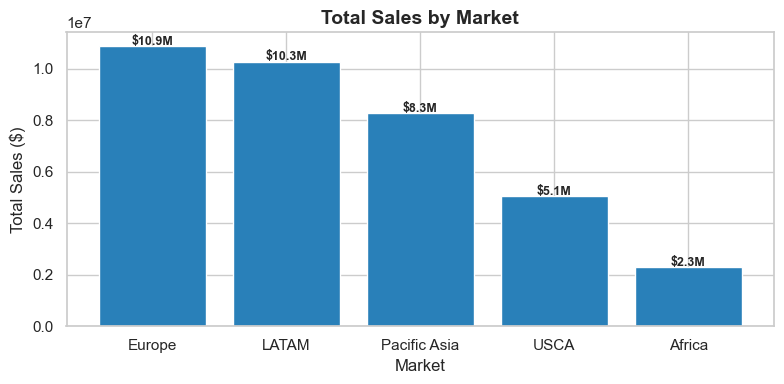

In [13]:
market_sales = fact_orders.groupby('market')['sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(market_sales.index, market_sales.values, color='#2980b9')

ax.set_title('Total Sales by Market', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Market')

for bar, val in zip(bars, market_sales.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'${val/1e6:.1f}M', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/01_sales_by_market.png', dpi=150)
plt.show()

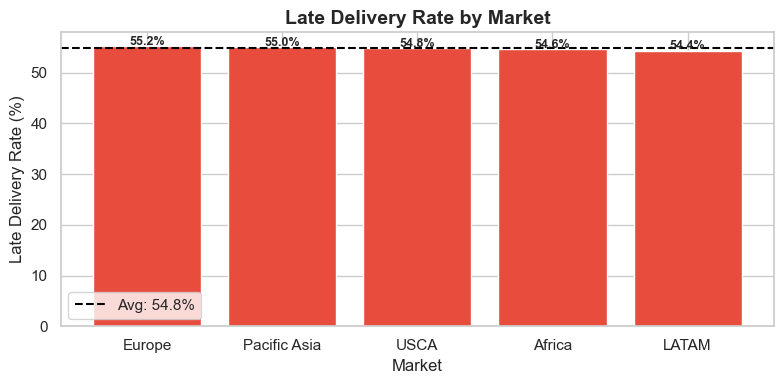

In [14]:
late_by_market = fact_orders.groupby('market')['late_delivery_risk'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(late_by_market.sort_values(ascending=False).index,
              late_by_market.sort_values(ascending=False).values,
              color='#e74c3c')

ax.set_title('Late Delivery Rate by Market', fontsize=14, fontweight='bold')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_xlabel('Market')
ax.axhline(y=late_by_market.mean(), color='black', 
           linestyle='--', linewidth=1.5, label=f'Avg: {late_by_market.mean():.1f}%')
ax.legend()

for bar, val in zip(bars, late_by_market.sort_values(ascending=False).values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/02_late_delivery_by_market.png', dpi=150)
plt.show()

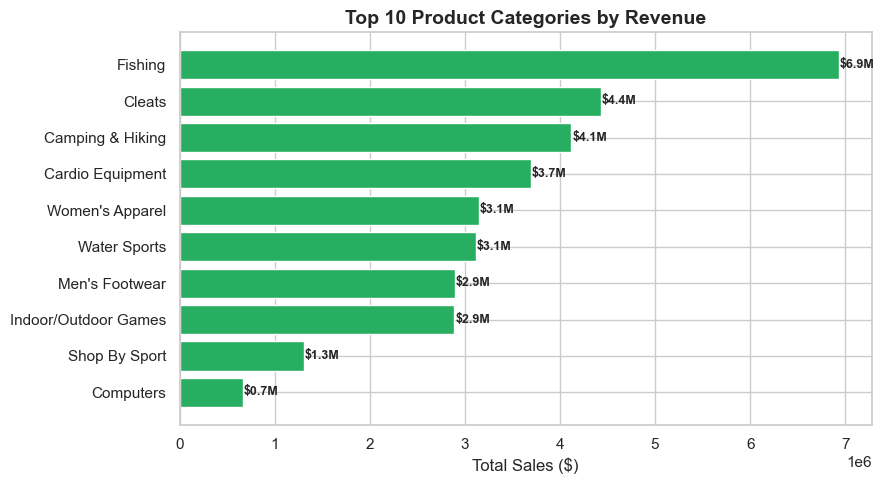

In [15]:
# Merge fact with categories
merged = fact_orders.merge(dim_categories, on='category_id')
cat_sales = merged.groupby('category_name')['sales'].sum().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(cat_sales.index, cat_sales.values, color='#27ae60')

ax.set_title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)')

for bar, val in zip(bars, cat_sales.values):
    ax.text(val + 10000, bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.1f}M', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/03_top_categories.png', dpi=150)
plt.show()

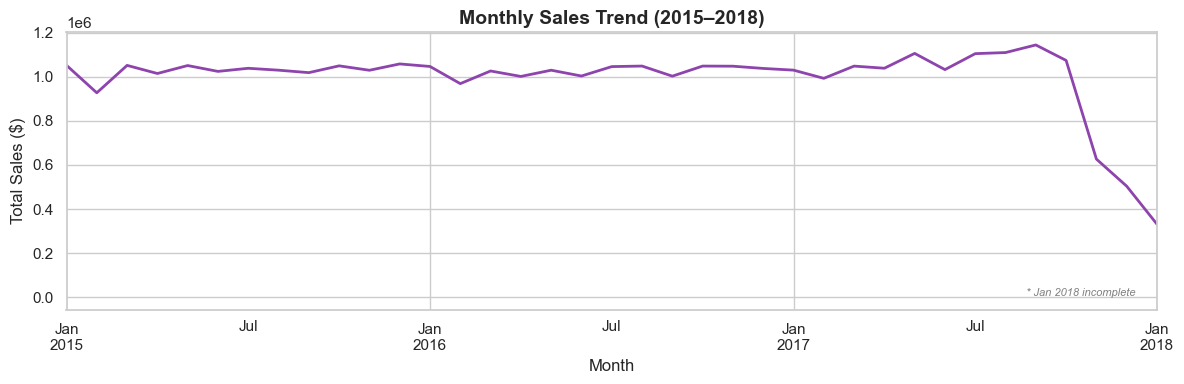

In [18]:
fact_orders['year_month'] = pd.to_datetime(fact_orders['order_date']).dt.to_period('M')
monthly_sales = fact_orders.groupby('year_month')['sales'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
monthly_sales.plot(ax=ax, color='#8e44ad', linewidth=2)

ax.set_title('Monthly Sales Trend (2015–2018)', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Month')
ax.fill_between(range(len(monthly_sales)), monthly_sales.values, alpha=0.2, color='#8e44ad')
ax.annotate('* Jan 2018 incomplete', xy=(0.98, 0.05),
            xycoords='axes fraction', fontsize=8,
            ha='right', color='gray', style='italic')

plt.tight_layout()
plt.savefig('../images/04_monthly_sales_trend.png', dpi=150)
plt.show()

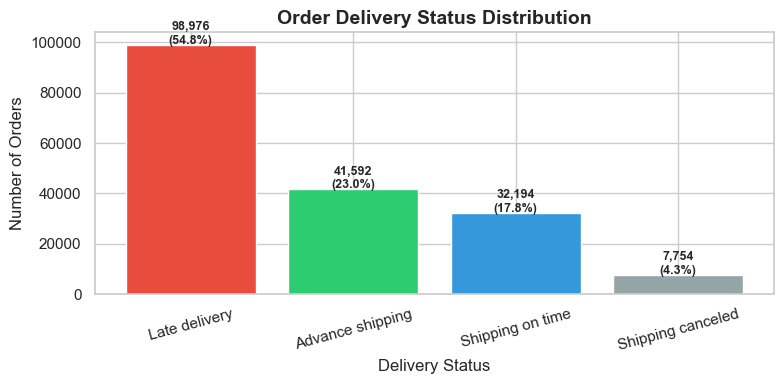

In [17]:
delivery_counts = fact_orders['delivery_status'].value_counts()
colors = ['#e74c3c', '#2ecc71', '#3498db', '#95a5a6']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(delivery_counts.index, delivery_counts.values, color=colors)

ax.set_title('Order Delivery Status Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Orders')
ax.set_xlabel('Delivery Status')
plt.xticks(rotation=15)

for bar, val in zip(bars, delivery_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({val/len(fact_orders)*100:.1f}%)',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/05_delivery_status.png', dpi=150)
plt.show()